# Notebook 09 — Bayesian Vasicek Stress Testing

## What are we doing here?

In Notebook 07, our Monte Carlo used PD = 0.19 as a **fixed number**.

In Notebook 08, we built a Bayesian model that gives us a **distribution** over PD —
not a single number, but an honest range of values consistent with the data.

Now we connect both: instead of plugging one PD into the Vasicek Monte Carlo,
we plug in **three PD values** from the posterior:

| Scenario | PD input | Interpretation |
|----------|---------|----------------|
| **Optimistic** | Posterior 5th percentile | Only 5% chance PD is this low |
| **Baseline** | Posterior mean | Best estimate of PD |
| **Stressed** | Posterior 95th percentile | Only 5% chance PD is this high — natural stress test |

The result: **three loss distributions**, giving you a stress-tested view of Economic Capital
without making up arbitrary numbers.

This is genuinely used in practice for LDP capital calibration.

---

## Why this matters for banking

When regulators ask: "What's your stressed PD assumption?"  
The answer is no longer arbitrary.  
The stressed PD is the **95th percentile of your posterior** — statistically grounded,
defensible, and derived directly from the data you have.

In [1]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, beta as beta_dist
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set()
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# =========================================================
# CELL 2: LOAD PORTFOLIO DATA
# =========================================================
"""
Load the ECL dataset from Notebook 06.
This contains PD, LGD, and EAD for each loan.
"""

import os

# Try multiple paths
possible_paths = [
    '../data/processed/ecl_dataset.csv',
    'data/processed/ecl_dataset.csv',
    'ecl_dataset.csv'
]

ecl_df = None
for path in possible_paths:
    if os.path.exists(path):
        ecl_df = pd.read_csv(path)
        print(f"✅ Loaded ECL dataset from: {path}")
        break

if ecl_df is None:
    raise FileNotFoundError(
        "Could not find ecl_dataset.csv. "
        "Please run Notebook 06 first to generate it."
    )

# Extract loan-level data
loan_pd_original = ecl_df['PD'].values
loan_lgd = ecl_df['LGD'].values
loan_ead = ecl_df['EAD'].values

n_loans = len(loan_pd_original)
total_exposure = loan_ead.sum()

print(f"\n📊 Portfolio Summary:")
print(f"   Number of loans:     {n_loans:,}")
print(f"   Total exposure:      ${total_exposure:,.0f}")
print(f"   Average PD:          {loan_pd_original.mean():.4f} ({loan_pd_original.mean()*100:.2f}%)")
print(f"   Average LGD:         {loan_lgd.mean():.4f} ({loan_lgd.mean()*100:.2f}%)")
print(f"   Average EAD:         ${loan_ead.mean():,.0f}")

✅ Loaded ECL dataset from: ../data/processed/ecl_dataset.csv

📊 Portfolio Summary:
   Number of loans:     230,795
   Total exposure:      $2,214,941,313
   Average PD:          0.1910 (19.10%)
   Average LGD:         0.9403 (94.03%)
   Average EAD:         $9,597


In [4]:
# =========================================================
# CELL 3: DEFINE BAYESIAN PD POSTERIOR (PORTFOLIO LEVEL)
# =========================================================
"""
We construct a portfolio-level PD posterior using the Beta-Binomial model.

Key idea:
Instead of using a fixed PD, we estimate a distribution over PD
based on observed portfolio behavior.

Important:
We use EXPECTED defaults (sum of PDs) rather than thresholding PDs.
This preserves model information and avoids arbitrary cutoffs.
"""

# ---------------------------------------------------------
# Portfolio-level data
# ---------------------------------------------------------

n_obs = len(loan_pd_original)

# Use expected defaults (continuous approximation)
D_obs = np.sum(loan_pd_original)

# Optional: integer version (for strict binomial interpretation)
D_obs_int = int(np.round(D_obs))

print("\n" + "="*60)
print("PORTFOLIO DEFAULT ESTIMATION")
print("="*60)
print(f"Number of loans (n): {n_obs:,}")
print(f"Expected defaults (Σ PD): {D_obs:.2f}")
print(f"Rounded defaults (Binomial approx): {D_obs_int}")
print(f"Implied MLE PD: {D_obs/n_obs:.4%}")

# ---------------------------------------------------------
# Prior (weakly informative)
# ---------------------------------------------------------
"""
Prior choice:
Beta(2,50) → mean ≈ 3.8%

Interpretation:
Represents a weak belief based on historical experience.
This prior is intentionally loose so that data dominates.
"""

alpha_prior = 2
beta_prior = 50

prior_mean = alpha_prior / (alpha_prior + beta_prior)

print("\nPrior:")
print(f"Beta({alpha_prior}, {beta_prior})")
print(f"Prior mean PD: {prior_mean:.4%}")

# ---------------------------------------------------------
# Posterior update (Beta-Binomial)
# ---------------------------------------------------------

alpha_post = alpha_prior + D_obs_int
beta_post = beta_prior + (n_obs - D_obs_int)

posterior_mean = alpha_post / (alpha_post + beta_post)

# Key percentiles (for stress testing)
pd_p5 = stats.beta.ppf(0.05, alpha_post, beta_post)
pd_p50 = stats.beta.ppf(0.50, alpha_post, beta_post)
pd_p95 = stats.beta.ppf(0.95, alpha_post, beta_post)

# Variance (uncertainty measure)
posterior_variance = (
    alpha_post * beta_post /
    ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))
)

print("\nPosterior:")
print(f"Beta({alpha_post:.0f}, {beta_post:.0f})")
print(f"Posterior mean PD: {posterior_mean:.4%}")
print(f"Posterior variance: {posterior_variance:.6f}")

print("\nPD Scenarios (from posterior):")
print(f"Optimistic (5th pct):  {pd_p5:.4%}")
print(f"Baseline  (mean):      {posterior_mean:.4%}")
print(f"Median    (50th pct):  {pd_p50:.4%}")
print(f"Stressed  (95th pct):  {pd_p95:.4%}")

print("="*60)

# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------

print("\n💡 Interpretation:")
print("• PD is not a single value — it is a distribution reflecting uncertainty")
print("• 5th percentile → optimistic scenario (low default environment)")
print("• 95th percentile → stress scenario (high default environment)")
print("• These scenarios are derived from data, not assumptions")
print("• Posterior variance quantifies uncertainty in PD estimation")


PORTFOLIO DEFAULT ESTIMATION
Number of loans (n): 230,795
Expected defaults (Σ PD): 44074.12
Rounded defaults (Binomial approx): 44074
Implied MLE PD: 19.0967%

Prior:
Beta(2, 50)
Prior mean PD: 3.8462%

Posterior:
Beta(44076, 186771)
Posterior mean PD: 19.0932%
Posterior variance: 0.000001

PD Scenarios (from posterior):
Optimistic (5th pct):  18.9588%
Baseline  (mean):      19.0932%
Median    (50th pct):  19.0931%
Stressed  (95th pct):  19.2279%

💡 Interpretation:
• PD is not a single value — it is a distribution reflecting uncertainty
• 5th percentile → optimistic scenario (low default environment)
• 95th percentile → stress scenario (high default environment)
• These scenarios are derived from data, not assumptions
• Posterior variance quantifies uncertainty in PD estimation


In [5]:
# =========================================================
# CELL: CREATE PD SCENARIOS FROM BAYESIAN POSTERIOR
# =========================================================

# Base portfolio PD
base_pd_mean = loan_pd_original.mean()

# Scaling factors
scale_mean = posterior_mean / base_pd_mean
scale_p5 = pd_p5 / base_pd_mean
scale_p95 = pd_p95 / base_pd_mean

# Apply scaling (preserve relative risk structure)
pd_baseline = np.clip(loan_pd_original * scale_mean, 1e-6, 1 - 1e-6)
pd_optimistic = np.clip(loan_pd_original * scale_p5, 1e-6, 1 - 1e-6)
pd_stressed = np.clip(loan_pd_original * scale_p95, 1e-6, 1 - 1e-6)

print("\nPD Scenario Summary:")
print(f"Original mean PD:   {base_pd_mean:.4%}")
print(f"Optimistic mean PD: {pd_optimistic.mean():.4%}")
print(f"Baseline mean PD:   {pd_baseline.mean():.4%}")
print(f"Stressed mean PD:   {pd_stressed.mean():.4%}")


PD Scenario Summary:
Original mean PD:   19.0967%
Optimistic mean PD: 18.9588%
Baseline mean PD:   19.0932%
Stressed mean PD:   19.2279%


In [6]:
# =========================================================
# CELL: FINAL VASICEK MONTE CARLO FUNCTION
# =========================================================

def run_vasicek_simulation(pd_values, rho, loan_lgd, loan_ead,
                          n_scenarios=10000, batch_size=500, seed=42):
    """
    Memory-efficient Vasicek Monte Carlo simulation.

    Parameters:
    -----------
    pd_values : ndarray
        Loan-level PDs (must match portfolio length)
    rho : float
        Asset correlation
    loan_lgd : ndarray
    loan_ead : ndarray
    n_scenarios : int
    batch_size : int
    seed : int

    Returns:
    --------
    losses : ndarray
        Portfolio loss distribution
    """

    np.random.seed(seed)

    n_loans = len(pd_values)
    losses = np.zeros(n_scenarios, dtype=np.float64)

    # Precompute constants
    inv_pd = norm.ppf(np.clip(pd_values, 1e-10, 1 - 1e-10))
    sqrt_rho = np.sqrt(rho)
    sqrt_one_minus_rho = np.sqrt(1 - rho)

    inv_pd = inv_pd.reshape(1, -1)
    loss_per_loan = loan_lgd * loan_ead

    n_batches = (n_scenarios + batch_size - 1) // batch_size

    print(f"\nRunning Vasicek simulation ({n_scenarios:,} scenarios)...")

    idx = 0
    for batch in range(n_batches):

        current_batch = min(batch_size, n_scenarios - idx)

        # Systematic factor
        Z = np.random.normal(0, 1, current_batch).reshape(-1, 1)

        # Conditional PD
        conditional_inv = (inv_pd - sqrt_rho * Z) / sqrt_one_minus_rho
        conditional_pd = norm.cdf(conditional_inv)

        # Default simulation
        U = np.random.uniform(0, 1, (current_batch, n_loans))
        defaults = (U < conditional_pd)

        # Loss calculation
        batch_losses = np.sum(defaults * loss_per_loan, axis=1)

        losses[idx:idx + current_batch] = batch_losses
        idx += current_batch

        if (batch + 1) % 5 == 0 or batch == n_batches - 1:
            print(f"   Completed batch {batch+1}/{n_batches}")

    print("Simulation complete.\n")

    return losses

In [8]:
# =========================================================
# CELL: RUN SCENARIOS 
# =========================================================

loss_opt = run_vasicek_simulation(pd_optimistic, rho, loan_lgd, loan_ead)
loss_base = run_vasicek_simulation(pd_baseline, rho, loan_lgd, loan_ead)
loss_stress = run_vasicek_simulation(pd_stressed, rho, loan_lgd, loan_ead)


Running Vasicek simulation (10,000 scenarios)...
   Completed batch 5/20
   Completed batch 10/20
   Completed batch 15/20
   Completed batch 20/20
Simulation complete.


Running Vasicek simulation (10,000 scenarios)...
   Completed batch 5/20
   Completed batch 10/20
   Completed batch 15/20
   Completed batch 20/20
Simulation complete.


Running Vasicek simulation (10,000 scenarios)...
   Completed batch 5/20
   Completed batch 10/20
   Completed batch 15/20
   Completed batch 20/20
Simulation complete.



In [10]:
# =========================================================
# CELL: RESULTS SUMMARY (FINAL METRICS)
# =========================================================

from scipy import stats

def summarize_losses(name, losses):
    el = np.mean(losses)
    var_999 = np.percentile(losses, 99.9)
    cvar_999 = np.mean(losses[losses >= var_999])
    ec = var_999 - el
    kurt = stats.kurtosis(losses, fisher=True)

    print(f"{name:12s} | EL={el:,.0f} | VaR99.9={var_999:,.0f} | EC={ec:,.0f} | Kurt={kurt:.2f}")
    
    return {
        "EL": el,
        "VaR_999": var_999,
        "CVaR_999": cvar_999,
        "EC": ec,
        "Kurtosis": kurt
    }


print("\n" + "="*90)
print("FINAL STRESS TEST RESULTS")
print("="*90)

results = {}
results["Optimistic"] = summarize_losses("Optimistic", loss_opt)
results["Baseline"]   = summarize_losses("Baseline", loss_base)
results["Stressed"]   = summarize_losses("Stressed", loss_stress)

print("="*90)


FINAL STRESS TEST RESULTS
Optimistic   | EL=393,784,997 | VaR99.9=681,913,977 | EC=288,128,980 | Kurt=0.16
Baseline     | EL=396,572,721 | VaR99.9=685,230,630 | EC=288,657,909 | Kurt=0.15
Stressed     | EL=399,371,103 | VaR99.9=689,121,343 | EC=289,750,240 | Kurt=0.15


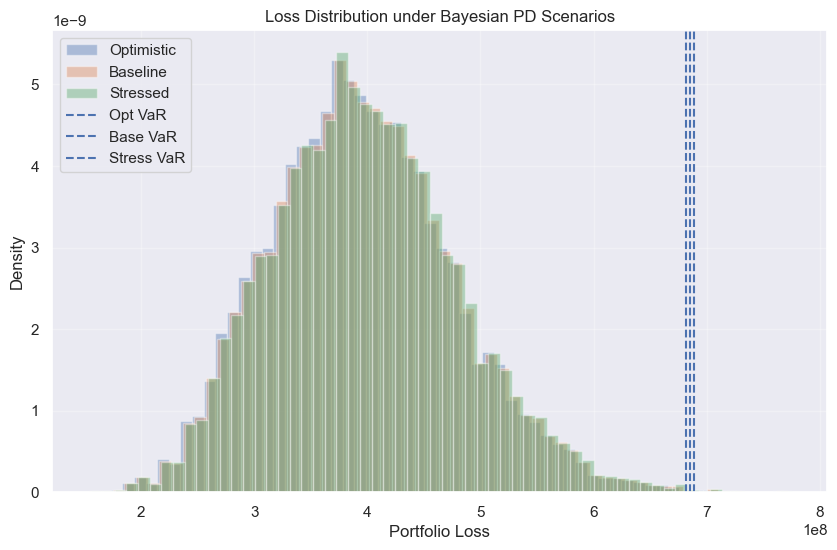

In [14]:
# =========================================================
# CELL: FINAL LOSS DISTRIBUTION COMPARISON (FIXED)
# =========================================================

plt.figure(figsize=(10,6))

# Histograms (IMPORTANT — you removed these earlier)
plt.hist(loss_opt, bins=60, alpha=0.4, label='Optimistic', density=True)
plt.hist(loss_base, bins=60, alpha=0.4, label='Baseline', density=True)
plt.hist(loss_stress, bins=60, alpha=0.4, label='Stressed', density=True)

# VaR lines (one per scenario)
plt.axvline(results["Optimistic"]["VaR_999"], linestyle='--', label='Opt VaR')
plt.axvline(results["Baseline"]["VaR_999"], linestyle='--', label='Base VaR')
plt.axvline(results["Stressed"]["VaR_999"], linestyle='--', label='Stress VaR')

plt.title("Loss Distribution under Bayesian PD Scenarios")
plt.xlabel("Portfolio Loss")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scenarios)...
   Completed batch 5/10
   Completed batch 10/10
Simulation complete.


Running Vasicek simulation (5,000 scena

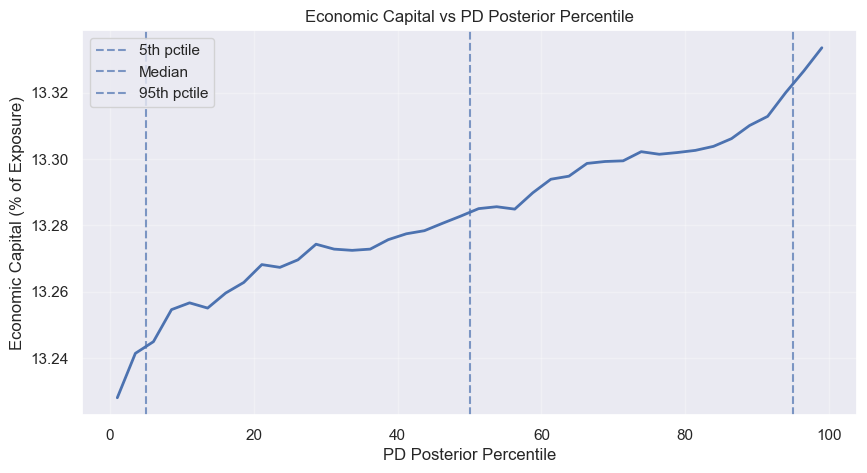


Key Points:
EC at 5th pct:  13.24%
EC at 50th pct: 13.29%
EC at 95th pct: 13.33%


In [16]:
# =========================================================
# SWEEP: ECONOMIC CAPITAL ACROSS POSTERIOR 
# =========================================================

pctiles = np.linspace(1, 99, 40)   # keep smaller (performance)
ec_pctile = []

base_pd_mean = loan_pd_original.mean()

for p in pctiles:
    
    # Step 1: get PD at percentile
    pd_scalar = stats.beta.ppf(p / 100, alpha_post, beta_post)
    
    # Step 2: scale loan-level PDs
    scale = pd_scalar / base_pd_mean
    pd_scaled = np.clip(loan_pd_original * scale, 1e-6, 1-1e-6)
    
    # Step 3: run simulation
    losses = run_vasicek_simulation(
        pd_scaled, rho, loan_lgd, loan_ead,
        n_scenarios=5000,   # reduce for speed
        batch_size=500
    )
    
    # Step 4: compute EC
    el = np.mean(losses)
    var_999 = np.percentile(losses, 99.9)
    ec = var_999 - el
    
    ec_pctile.append(ec)

ec_pctile = np.array(ec_pctile)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(pctiles, 100 * ec_pctile / total_exposure, linewidth=2)

plt.axvline(5,  linestyle='--', alpha=0.7, label='5th pctile')
plt.axvline(50, linestyle='--', alpha=0.7, label='Median')
plt.axvline(95, linestyle='--', alpha=0.7, label='95th pctile')

plt.xlabel('PD Posterior Percentile')
plt.ylabel('Economic Capital (% of Exposure)')
plt.title('Economic Capital vs PD Posterior Percentile')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ---------------------------------------------------------
# Key points
# ---------------------------------------------------------

print("\nKey Points:")
print(f"EC at 5th pct:  {100*ec_pctile[np.searchsorted(pctiles,5)]/total_exposure:.2f}%")
print(f"EC at 50th pct: {100*ec_pctile[np.searchsorted(pctiles,50)]/total_exposure:.2f}%")
print(f"EC at 95th pct: {100*ec_pctile[np.searchsorted(pctiles,95)]/total_exposure:.2f}%")

---
## End of Notebook 09

✔ Three-scenario Bayesian Vasicek stress test (optimistic / baseline / stressed)  
✔ Each scenario's PD derived from posterior percentiles — no arbitrary assumptions  
✔ EL, VaR 99.9%, CVaR, Economic Capital under all three scenarios  
✔ Full posterior sensitivity sweep: EC vs PD posterior percentile  
✔ Defensible stress test narrative for regulatory discussions  



---

## The complete project narrative 

Starting from raw Lending Club data:

1. **Data preparation** — cleaned 230k loans, defined default indicator, removed leakage variables
2. **Variable diagnostics** — WoE binning, IV selection, multicollinearity checks
3. **PD model** — logistic regression, AUC 0.70, KS 0.30, calibrated with intercept adjustment
4. **LGD model** — two-stage hurdle model, Stage 1 AUROC 0.67, Stage 2 R² ~0.09
5. **EAD model** — CCF regression, applied to full portfolio
6. **ECL = PD × LGD × EAD** — loan-level and year-on-year portfolio analysis
7. **Rho estimation** — Vasicek moment estimator, ρ ≈ 0.025, consistent with Basel retail floors
8. **Monte Carlo** — 10,000 scenarios, antithetic variates, VaR/CVaR/Economic Capital
9. **Bayesian PD** — Beta-Binomial posterior, credible intervals, sequential updating
10. **Bayesian stress test** — posterior percentiles as natural stress scenarios, defensible capital range